# Cvičenie: Predikcia platu pomocou neurónovej siete

**Dataset:** `data/job_salary_prediction_dataset.csv`  
**Úloha:** Regresia — predikuj ročný plat na základe pracovných charakteristík  
**Architektúra:** MLP (Multi-Layer Perceptron)  

---

### Postup (workflow)
1. Načítaj a preskúmaj dáta
2. One-Hot Encoding kategorických stĺpcov
3. Rozdeľ dataset na train / val / test
4. Štandardizuj features (fit iba na train!)
5. Vytvor PyTorch DataLoader-y
6. Definuj model
7. Trénuj s early stopping
8. Vyhodnoť na testovacej množine

## Pre začiatočníkov: o čom to celé je?

Predstav si tabuľku s informáciami o zamestnancoch (skúsenosti, vzdelanie, odvetvie, krajina...) a ich platom. Chceme model, ktorý sa pozrie na nového človeka a **odhadne jeho plat**. Toto je tzv. **regresná úloha** — predikujeme spojitú číselnú hodnotu (nie kategóriu).

**Neurónová sieť** je matematický model, ktorý sa učí vzorce z príkladov:
- má vrstvy "neurónov" prepojených číslami (**váhy**)
- pri tréningu si tieto váhy postupne upravuje, aby jej predikcie boli čo najbližšie k pravde
- výsledkom je funkcia, ktorá z vstupných znakov (features) vypočíta odhadovaný plat

### Slovník pojmov, ktoré budeš v tomto notebooku stretávať

| Pojem | Čo to je |
|---|---|
| **Feature** | Jeden vstupný znak (napr. počet rokov skúseností) |
| **Target / label** | To, čo predikujeme (tu: plat) |
| **Trénovacia / validačná / testovacia množina** | Tri časti dát — model sa učí na trénovacej, ladíme ho podľa validačnej, finálne testujeme na testovacej |
| **Loss (chybová funkcia)** | Číslo, ktoré hovorí, ako veľmi sa model mýli — chceme ho minimalizovať |
| **Optimizer** | Algoritmus, ktorý postupne upravuje váhy modelu, aby loss klesala |
| **Epocha** | Jeden prechod modelu cez všetky tréningové dáta |
| **Batch** | Malá skupinka vzoriek, ktorú spracujeme naraz (efektívnejšie ako jedna po jednej) |
| **Overfitting (pretrénovanie)** | Model sa naučil tréningové dáta naspamäť, ale na nových sa správa zle |
| **Early stopping** | Technika: zastavíme tréning, keď sa model prestáva zlepšovať na validačných dátach |


## 0. Importy

Načítame si potrebné knižnice:
- **`torch`** — PyTorch, knižnica pre neurónové siete
- **`pandas` / `numpy`** — práca s tabuľkovými / číselnými dátami
- **`matplotlib`** — kreslenie grafov
- **`sklearn.train_test_split`** — pomocník na rozdelenie dát na train/val/test

Ak je dostupná **GPU** (grafická karta), tréning bude na nej oveľa rýchlejší.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Ak je dostupná CUDA (NVIDIA GPU), použijeme ju — tréning bude rádovo rýchlejší
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Zariadenie: {device}")
kagglehub.dataset_download("nalisha/job-salary-prediction-dataset", output_dir="./data")


Zariadenie: cuda


'./data'

## 1. Načítanie a prieskum datasetu

Stĺpce v datasete:
- **Numerické:** `experience_years`, `skills_count`, `certifications`
- **Kategorické:** `job_title`, `education_level`, `industry`, `company_size`, `location`, `remote_work`
- **Target:** `salary` (ročný plat v USD)

In [2]:
df = pd.read_csv("data/job_salary_prediction_dataset.csv")

print(df.shape)
df.head()

(250000, 10)


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [4]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [5]:
print("Chýbajúce hodnoty:")
print(df.isnull().sum())

Chýbajúce hodnoty:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


In [6]:
cat_cols = ["job_title", "education_level", "industry", "company_size", "location", "remote_work"]

for col in cat_cols:
    print(df[col].nunique(), df[col].unique())

12 <StringArray>
[              'AI Engineer',              'Data Analyst',
        'Frontend Developer',          'Business Analyst',
           'Product Manager',         'Backend Developer',
 'Machine Learning Engineer',           'DevOps Engineer',
         'Software Engineer',     'Cybersecurity Analyst',
            'Data Scientist',            'Cloud Engineer']
Length: 12, dtype: str
5 <StringArray>
['Bachelor', 'PhD', 'High School', 'Diploma', 'Master']
Length: 5, dtype: str
10 <StringArray>
[   'Healthcare',       'Telecom',         'Media',        'Retail',
 'Manufacturing',     'Education',       'Finance',    'Technology',
    'Consulting',    'Government']
Length: 10, dtype: str
5 <StringArray>
['Medium', 'Small', 'Large', 'Enterprise', 'Startup']
Length: 5, dtype: str
10 <StringArray>
[      'India',   'Australia',   'Singapore',      'Canada',      'Sweden',
         'USA', 'Netherlands',      'Remote',     'Germany',          'UK']
Length: 10, dtype: str
3 <StringArray>

## 2. One-Hot Encoding (OHE)

**Problém:** Neurónová sieť pozná iba čísla — netuší, čo je "Bachelor" alebo "India". Kategorické (textové) stĺpce musíme zakódovať na čísla.

**Riešenie — One-Hot Encoding:** každá kategória dostane **vlastný binárny stĺpec** (0 alebo 1). Jedna a tá istá vzorka má presne jednu jednotku v skupine stĺpcov pre danú kategorickú vlastnosť.

Príklad pre stĺpec `remote_work` s hodnotami `No / Hybrid / Yes`:
```
remote_work    →   remote_work_Hybrid   remote_work_Yes
"No"                      0                   0
"Hybrid"                  1                   0
"Yes"                     0                   1
```

> **Prečo nie len "No=0, Hybrid=1, Yes=2"?**
> Sieť by si myslela, že "Yes" je dvakrát viac ako "Hybrid", čo je nezmysel — kategórie nemajú prirodzené poradie.

**`drop_first=True`** odstráni prvú kategóriu z každej skupiny — je nadbytočná (ak sú obidva ostatné stĺpce 0, hodnota musela byť tá vynechaná). Pomáha to predísť multikolinearite.

**Dôležité:** OHE robíme na **celom DataFrame pred** rozdelením na train/test, aby všetky tri sety mali presne tie isté stĺpce.


In [7]:
num_cols = ["experience_years", "skills_count", "certifications"]
target_col = "salary"

# pd.get_dummies vytvorí binárne stĺpce pre každú kategóriu
# drop_first=True odstráni prvú kategóriu zo skupiny (predchádza multikolinearite)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Počet stĺpcov pred OHE: {df.shape[1]}")
print(f"Počet stĺpcov po OHE:   {df_encoded.shape[1]}")
print()
print("Stĺpce po OHE:")
print(df_encoded.columns.tolist())


Počet stĺpcov pred OHE: 10
Počet stĺpcov po OHE:   43

Stĺpce po OHE:
['experience_years', 'skills_count', 'certifications', 'salary', 'job_title_Backend Developer', 'job_title_Business Analyst', 'job_title_Cloud Engineer', 'job_title_Cybersecurity Analyst', 'job_title_Data Analyst', 'job_title_Data Scientist', 'job_title_DevOps Engineer', 'job_title_Frontend Developer', 'job_title_Machine Learning Engineer', 'job_title_Product Manager', 'job_title_Software Engineer', 'education_level_Diploma', 'education_level_High School', 'education_level_Master', 'education_level_PhD', 'industry_Education', 'industry_Finance', 'industry_Government', 'industry_Healthcare', 'industry_Manufacturing', 'industry_Media', 'industry_Retail', 'industry_Technology', 'industry_Telecom', 'company_size_Large', 'company_size_Medium', 'company_size_Small', 'company_size_Startup', 'location_Canada', 'location_Germany', 'location_India', 'location_Netherlands', 'location_Remote', 'location_Singapore', 'location_Swe

In [8]:
# X = matica vstupných featúr (všetky stĺpce okrem targetu)
# y = vektor cieľových hodnôt (plat)
# float32 stačí na presnosť a je rýchlejšie ako float64
X = df_encoded.drop(columns=[target_col]).values.astype("float32")
y = df_encoded[target_col].values.astype("float32")

print(f"X tvar: {X.shape}")
print(f"y tvar: {y.shape}")
print(f"Rozsah platov: {y.min():.0f} – {y.max():.0f} USD")


X tvar: (250000, 42)
y tvar: (250000,)
Rozsah platov: 31867 – 333046 USD


## 3. Rozdelenie datasetu

Dáta rozdelíme na **tri** disjunktné množiny v pomere **70 / 15 / 15 %**:

| Množina | Načo slúži |
|---|---|
| **Train** (70 %) | Tieto dáta model vidí a učí sa z nich |
| **Validation** (15 %) | Sledujeme na nich výkon počas tréningu, podľa nich rozhodujeme o early stopping |
| **Test** (15 %) | Model ich **nikdy nevidí počas tréningu** — používame ich až na úplnom konci, aby sme dostali čestný odhad výkonu na nových dátach |

> **Prečo až tri množiny?**
> Keby sme model ladili podľa testovacích dát, "podviedli" by sme sa — model by sa nepriamo dozvedel niečo o tých dátach a finálne číslo by bolo nadhodnotené. Validačná množina je preto medzistupeň.

`train_test_split` rozdeľuje dáta naraz iba na dve časti, takže to spravíme v dvoch krokoch:
1. Oddelíme test (15 % z celku) → ostane train+val (85 %)
2. Z train+val oddelíme val (15/85 ≈ 17.6 % z train+val) → ostane train (70 % z celku)


## 4. Štandardizácia features

Predstav si, že máš dva features: `experience_years` (rozsah 0–20) a `salary` (desiatky tisíc). Sieť bude pri tréningu nedisciplinovaná — väčšie čísla budú dominovať a učenie bude pomalé alebo nestabilné.

**Riešenie — štandardizácia:** každý stĺpec posunieme tak, aby mal priemer 0 a smerodajnú odchýlku 1:

$$x' = \frac{x - \mu}{\sigma}$$

Po tejto úprave sú všetky features v podobnom rozsahu a sieť sa učí oveľa lepšie.

> **Kľúčové pravidlo:** `μ` (priemer) a `σ` (smerodajná odchýlka) **vypočítaj iba z trénovacích dát**, a tie isté hodnoty potom aplikuj aj na val a test.
>
> **Prečo?** V reálnom nasadení nemáme prístup k budúcim dátam. Ak by sme do `μ`/`σ` zahrnuli aj test, model by "videl" trochu informácií z testu už pri tréningu (tzv. **data leakage**) a meranie výkonu by bolo skreslené.

Plat (`y`) štandardizujeme z rovnakého dôvodu — sieti sa lepšie predikuje, keď je výstup blízko nuly. Pri vyhodnotení predikcie zase odštandardizujeme späť do USD.


In [9]:
# random_state=67 — pevný seed, aby rozdelenie bolo reprodukovateľné (pri opakovanom spustení dostaneme to isté)
SEED = 67

# Krok 1: oddelíme test (15 % z celého datasetu)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15, random_state=SEED
)

# Krok 2: z train+val (85 %) oddelíme val tak, aby tvoril 15 % z pôvodného datasetu
# 0.15 / 0.85 ≈ 0.176 → toľko z train+val musí ísť do val
n_val = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=n_val, random_state=SEED
)
print(f"Train: {X_train.shape[0]} vzoriek")
print(f"Val:   {X_val.shape[0]} vzoriek")
print(f"Test:  {X_test.shape[0]} vzoriek")
assert X_train.shape[0] + X_val.shape[0] + X_test.shape[0] == df.shape[0]


Train: 175000 vzoriek
Val:   37500 vzoriek
Test:  37500 vzoriek


In [10]:
# Spočítame priemer a smerodajnú odchýlku IBA z trénovacích dát (žiadne pozeranie do val/test!)
# +1e-6 pri sigma chráni pred delením nulou, ak by mal nejaký stĺpec konštantnú hodnotu
mu = X_train.mean(axis=0, keepdims=True)
sigma = X_train.std(axis=0, keepdims=True) + 1e-6

# Štandardizácia targetu (platu) — sieti sa lepšie predikuje, keď je výstup blízko nuly
# Pri vyhodnotení predikciu odštandardizujeme späť: y_usd = y_std * sigma_y + mu_y
mu_y, sigma_y = y_train.mean(), y_train.std()
y_train_s = (y_train - mu_y) / sigma_y
y_val_s   = (y_val   - mu_y) / sigma_y
y_test_s  = (y_test  - mu_y) / sigma_y

# Tie isté mu/sigma z trainu aplikujeme na val aj test (nepočítame nové!)
X_train_s = (X_train - mu) / sigma
X_val_s   = (X_val   - mu) / sigma
X_test_s  = (X_test  - mu) / sigma

print(f"X_train_s — priemer: {X_train_s.mean():.4f}, std: {X_train_s.std():.4f}")
print(f"X_val_s   — priemer: {X_val_s.mean():.4f}, std: {X_val_s.std():.4f}")
print(f"y_train_s - priemer: {y_train_s.mean():.4f}, std: {y_train_s.std():.4f}")


X_train_s — priemer: 0.0000, std: 1.0003
X_val_s   — priemer: 0.0009, std: 1.0005
y_train_s - priemer: -0.0000, std: 1.0000


## 5. PyTorch DataLoader

PyTorch pracuje s `Tensor`-mi, nie s numpy poľami.  
`TensorDataset` zbalí X a y do jedného objektu, `DataLoader` z neho robí mini-batche.

Pre **train** nastavíme `shuffle=True` (náhodné poradie batchov — zabraňuje memorovaniu poradia).  
Pre **val/test** `shuffle=False` (poradie nevadí, len vyhodnocujeme).

In [11]:
BATCH_SIZE = 512  # koľko vzoriek spracujeme naraz v jednom kroku

# PyTorch pracuje s tenzormi (nie numpy poľami). FloatTensor = 32-bitové float čísla.
# .unsqueeze(1) pridá dimenziu z [N] na [N, 1] — sieť očakáva tvar [batch, výstupy]
X_train_t = torch.FloatTensor(X_train_s)
y_train_t = torch.FloatTensor(y_train_s).unsqueeze(1)
X_val_t   = torch.FloatTensor(X_val_s)
y_val_t   = torch.FloatTensor(y_val_s).unsqueeze(1)
X_test_t  = torch.FloatTensor(X_test_s)
y_test_t  = torch.FloatTensor(y_test_s).unsqueeze(1)

# TensorDataset spáruje X a y do jedného objektu (vzorka i: (X[i], y[i]))
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

# DataLoader z datasetu vytvára mini-batche.
# shuffle=True pre train — náhodné poradie zabraňuje, aby sa sieť učila poradie vzoriek
# shuffle=False pre val/test — poradie je jedno, len vyhodnocujeme
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# Overenie — pozrieme sa na tvary jedného batchu
X_batch, y_batch = next(iter(train_loader))
print(f"Batch X tvar: {X_batch.shape}")
print(f"Batch y tvar: {y_batch.shape}")


Batch X tvar: torch.Size([512, 42])
Batch y tvar: torch.Size([512, 1])


## 6. Definícia modelu

Postavíme jednoduchý **MLP** (*Multi-Layer Perceptron* — viacvrstvový perceptrón). To je najzákladnejšia neurónová sieť: niekoľko za sebou zoradených **plne prepojených vrstiev** (`Linear`) preložených **aktivačnými funkciami** (`ReLU`).

```
vstup (input_dim) → Linear → ReLU → Linear → ReLU → Linear → výstup (1)
                    [128]           [64]
```

**Čo robí ktorá časť?**
- **`nn.Linear(in, out)`** — lineárna transformácia: `y = W·x + b`. Tu sa "učia" váhy `W` a posuny `b`.
- **`nn.ReLU()`** — `max(0, x)`, vyhadzuje záporné čísla. Vďaka tejto nelinearite vie sieť modelovať aj zložité vzťahy (bez nej by celý MLP bol len jedna lineárna funkcia).
- **Žiadna aktivácia na výstupe** — pre regresiu chceme, aby sieť mohla vrátiť ľubovoľné reálne číslo (nielen napr. 0–1).

**Loss funkcia: `MSELoss`** (Mean Squared Error, stredná kvadratická chyba) — priemer štvorcov rozdielov medzi predikciou a skutočnosťou. Veľké chyby trestá silnejšie ako malé.


In [12]:
class SalaryMLP(nn.Module):
    """Jednoduchý MLP: vstup → 128 → 64 → 1."""

    def __init__(self, input_dim):
        super().__init__()
        # nn.Sequential spustí vrstvy postupne, jednu za druhou
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),  # plne prepojená vrstva: 42 vstupov → 128 neurónov
            nn.ReLU(),                  # nelinearita: max(0, x)
            nn.Linear(128, 64),         # 128 → 64
            nn.ReLU(),
            nn.Linear(64, 1),           # 64 → 1 (predikovaný plat, bez aktivácie)
        )

    def forward(self, x):
        # forward = ako sa spočíta výstup zo vstupu
        return self.net(x)


input_dim = X_train_t.shape[1]
model = SalaryMLP(input_dim).to(device)  # presunieme model na GPU/CPU
print(model)
print(f"\nPočet parametrov: {sum(p.numel() for p in model.parameters()):,}")


SalaryMLP(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

Počet parametrov: 13,825


## 7. Konfigurácia trénovania

- **Loss (`MSELoss`)** — povie nám, ako veľmi sa model mýli. Tréning = minimalizovanie tejto loss.
- **Optimizer (`Adam`)** — algoritmus, ktorý na základe loss upravuje váhy modelu. **Adam** je adaptívny (sám si upravuje rýchlosť učenia pre každú váhu) a funguje dobre v drvivej väčšine prípadov.
- **Learning rate (`lr=1e-3`)** — ako veľký krok urobiť pri každej aktualizácii váh. Príliš veľký = preskakujeme cez optimum, príliš malý = učenie je pomalé.
- **Epochy (`EPOCHS=200`)** — koľkokrát najviac prejdeme cez trénovaciu množinu.
- **Patience (`PATIENCE=20`)** — koľko epôch bez zlepšenia validačnej loss tolerujeme, kým ukončíme tréning (early stopping).


In [13]:
criterion = nn.MSELoss()  # MSE = priemer (predikcia − skutočnosť)²

LEARNING_RATE = 1e-3   # dĺžka kroku pri aktualizácii váh
EPOCHS  = 200          # max počet prechodov cez tréningovú množinu
PATIENCE = 20          # po koľkých epochách bez zlepšenia val loss zastavíme tréning

# Adam — adaptívny optimizer, dobrá voľba pre väčšinu úloh
opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


## 8. Trénovanie

### Funkcia `run_epoch`

Jedna **epocha** = jeden prechod cez všetky dáta v loaderi (po batchoch). Funkcia robí presne toto a vracia priemernú loss + MAE za celú epochu.

**Čo sa deje pri tréningu (`training=True`)?** Pre každý batch:
1. **Forward pass** — pošleme dáta sieťou a získame predikciu
2. Spočítame **loss** (ako veľmi sa sieť pomýlila)
3. **Backward pass** — spočítame gradienty (smer, ktorým má každá váha ísť, aby sa loss zmenšila)
4. **Optimizer step** — upravíme váhy podľa gradientov

**Pri vyhodnotení (`training=False`)** robíme iba krok 1 (forward) — váhy nemeníme a vypneme počítanie gradientov (`torch.no_grad()`), aby to bolo rýchlejšie a šetrnejšie k pamäti.

**MAE** (Mean Absolute Error) = priemerná absolútna chyba v USD. Lepšie sa interpretuje ako MSE — povie nám, *o koľko dolárov* sa model v priemere pomýli.


In [14]:
def run_epoch(loader, training: bool):
    """Jeden prechod cez celý loader. Vracia (priemerná MSE loss, priemerná MAE v USD)."""
    # Prepneme model do tréningového/eval režimu
    # (ovplyvňuje napr. Dropout, BatchNorm — tu zatiaľ nemáme, ale je to dobrý zvyk)
    model.train(training)

    total_loss = 0.0
    total_mae  = 0.0
    total_n    = 0

    # Pri vyhodnotení vypneme počítanie gradientov — šetrí pamäť aj čas
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X_b, y_b in loader:
            # Presun batchu na GPU (ak je dostupná)
            X_b, y_b = X_b.to(device), y_b.to(device)

            if training:
                opt.zero_grad()  # vynulujeme gradienty z predošlého kroku (PyTorch ich akumuluje)

            logits = model(X_b)              # forward pass: predikcia
            loss = criterion(logits, y_b)    # ako veľmi sa sieť pomýlila

            if training:
                loss.backward()  # backward pass: spočíta gradienty pre každú váhu
                opt.step()       # optimizer použije gradienty na úpravu váh

            # Zbierame štatistiky (násobíme veľkosťou batchu, neskôr delíme celkovým počtom)
            n = X_b.size(0)
            total_loss += loss.item() * n
            # MAE prevedieme zo štandardizovaných jednotiek späť na USD vynásobením sigma_y
            total_mae  += (torch.abs(logits - y_b) * sigma_y).sum().item()
            total_n    += n

    return total_loss / total_n, total_mae / total_n


In [15]:
# Sem si budeme ukladať metriky z každej epochy — neskôr ich vykreslíme
history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

# Stav pre early stopping
best_val_loss = float("inf")  # najlepšia (najnižšia) val loss, akú sme zatiaľ videli
best_state    = None          # snímka váh modelu z najlepšej epochy
patience_cnt  = 0             # počítadlo epôch bez zlepšenia

for epoch in range(1, EPOCHS + 1):
    # Tréning na trénovacích dátach (váhy sa menia)
    train_loss, train_mae = run_epoch(train_loader, True)
    # Vyhodnotenie na validačných dátach (váhy sa NEmenia)
    val_loss, val_mae = run_epoch(val_loader, False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    # Občas vypíšeme priebeh (každú 10. epochu)
    if epoch % 10 == 0:
        print(f"Ep {epoch:3d} | train MSE: {train_loss:10.5f}  MAE: {train_mae:7.5f} "
              f"| val MSE: {val_loss:10.5f}  MAE: {val_mae:7.5f}")

    # Early stopping: ak sa val loss zlepšila, zapamätáme si stav modelu a resetujeme počítadlo
    # 1e-4 je tolerancia — drobné výkyvy nepovažujeme za zlepšenie
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        patience_cnt  = 0
        # Uložíme si snímku všetkých váh (klonujeme, aby ich neskôr nezmenil ďalší tréning)
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_cnt += 1
        # Ak sa N epôch nezlepšilo, ukončíme tréning — model sa už pravdepodobne začína pretrénovávať
        if patience_cnt >= PATIENCE:
            print("Early stopping: ")
            break

# Obnovíme váhy z epochy s najlepšou val_loss (inak by test bežal na potenciálne pretrénovanom stave)
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print(f"Obnovené váhy z najlepšej epochy (val MSE = {best_val_loss:.5f}).")

print("\nTréning dokončený.")


Ep  10 | train MSE:    0.01851  MAE: 4055.70564 | val MSE:    0.01933  MAE: 4153.01139
Ep  20 | train MSE:    0.01811  MAE: 4011.02236 | val MSE:    0.01897  MAE: 4109.97739
Ep  30 | train MSE:    0.01781  MAE: 3978.08421 | val MSE:    0.01894  MAE: 4106.06166
Early stopping: 
Obnovené váhy z najlepšej epochy (val MSE = 0.01891).

Tréning dokončený.


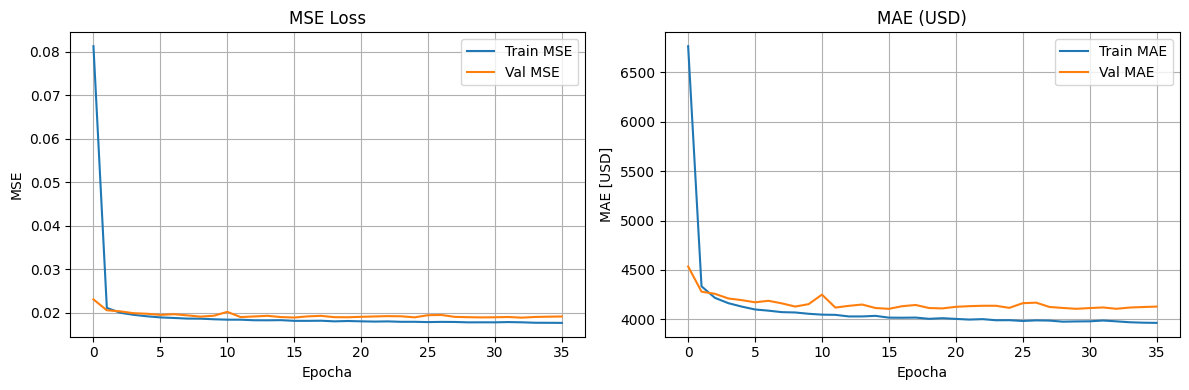

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train MSE")
axes[0].plot(history["val_loss"],   label="Val MSE")
axes[0].set_title("MSE Loss")
axes[0].set_xlabel("Epocha")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history["train_mae"], label="Train MAE")
axes[1].plot(history["val_mae"],   label="Val MAE")
axes[1].set_title("MAE (USD)")
axes[1].set_xlabel("Epocha")
axes[1].set_ylabel("MAE [USD]")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 9. Vyhodnotenie na testovacej množine

Toto je **moment pravdy** — testovacia množina je úplne čerstvá, model ju počas tréningu nikdy nevidel. Ak vyjdú dobré čísla aj tu, môžeme veriť, že model bude rozumne fungovať aj na úplne nových ľuďoch.

**Vizualizácie pomáhajú pochopiť, *kde* sa model mýli:**
- **Scatter plot** predikcia vs. skutočnosť — body blízko diagonály = dobrá predikcia. Ak sa model systematicky podhadnocuje pri vysokých platoch, uvidíš to ako oblak nad diagonálou.
- **Histogram reziduálov** (chýb) — ideálne by malo byť rozdelenie symetrické okolo nuly. Ak je posunuté, model má systematický bias (napr. všetkým predikuje príliš nízko).


In [17]:
# Finálne vyhodnotenie na testovacej množine — model tieto dáta NIKDY počas tréningu nevidel
test_loss, test_mae = run_epoch(test_loader, training=False)
print(f"Test MSE: {test_loss:,.5f}")           # MSE v štandardizovaných jednotkách
print(f"Test MAE: {test_mae:,.1f} USD")        # priemerná chyba v dolároch — ľahko interpretovateľné


Test MSE: 0.01887
Test MAE: 4,096.9 USD


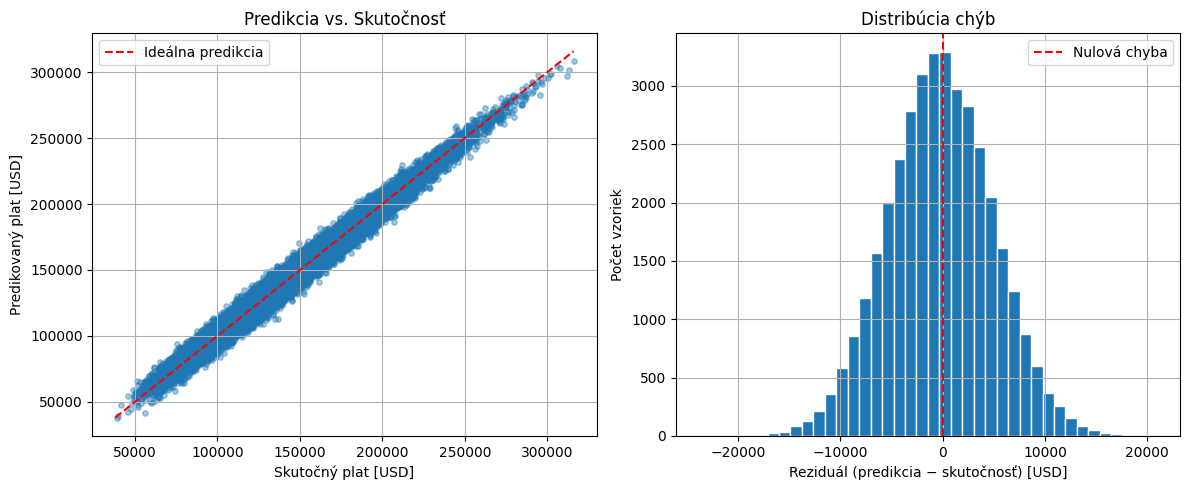

In [18]:
model.eval()
all_preds  = []
all_actual = []

with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b = X_b.to(device)
        preds = model(X_b).cpu().numpy()
        all_preds.append(preds)
        all_actual.append(y_b.numpy())

all_preds  = np.concatenate(all_preds).flatten() * sigma_y + mu_y
all_actual = np.concatenate(all_actual).flatten() * sigma_y + mu_y

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
axes[0].scatter(all_actual, all_preds, alpha=0.4, s=15)
mn = min(all_actual.min(), all_preds.min())
mx = max(all_actual.max(), all_preds.max())
axes[0].plot([mn, mx], [mn, mx], "r--", label="Ideálna predikcia")
axes[0].set_xlabel("Skutočný plat [USD]")
axes[0].set_ylabel("Predikovaný plat [USD]")
axes[0].set_title("Predikcia vs. Skutočnosť")
axes[0].legend()
axes[0].grid(True)

# Histogram reziduálov
residuals = all_preds - all_actual
axes[1].hist(residuals, bins=40, edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", label="Nulová chyba")
axes[1].set_xlabel("Reziduál (predikcia − skutočnosť) [USD]")
axes[1].set_ylabel("Počet vzoriek")
axes[1].set_title("Distribúcia chýb")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 10. Feature importance (zero-out analýza)

Pre každú vstupnú featúru zmeráme, **o koľko stúpne test MAE**, keď ju vynulujeme v štandardizovanom priestore (≈ nahradenie priemerom z train). Väčší nárast MAE = dôležitejšia featúra pre predikciu.

Vizualizujeme **top 10** najdôležitejších featúr.

Baseline test MAE: 4,096.9 USD

Top 10 featúr (Δ MAE po vynulovaní):
  experience_years                         +10570.1 USD
  company_size_Startup                      +9329.3 USD
  company_size_Small                        +7276.1 USD
  company_size_Medium                       +5097.4 USD
  job_title_Data Analyst                    +5014.9 USD
  location_India                            +4823.7 USD
  job_title_Business Analyst                +4777.6 USD
  location_USA                              +4305.2 USD
  education_level_PhD                       +3717.2 USD
  job_title_Frontend Developer              +3527.8 USD


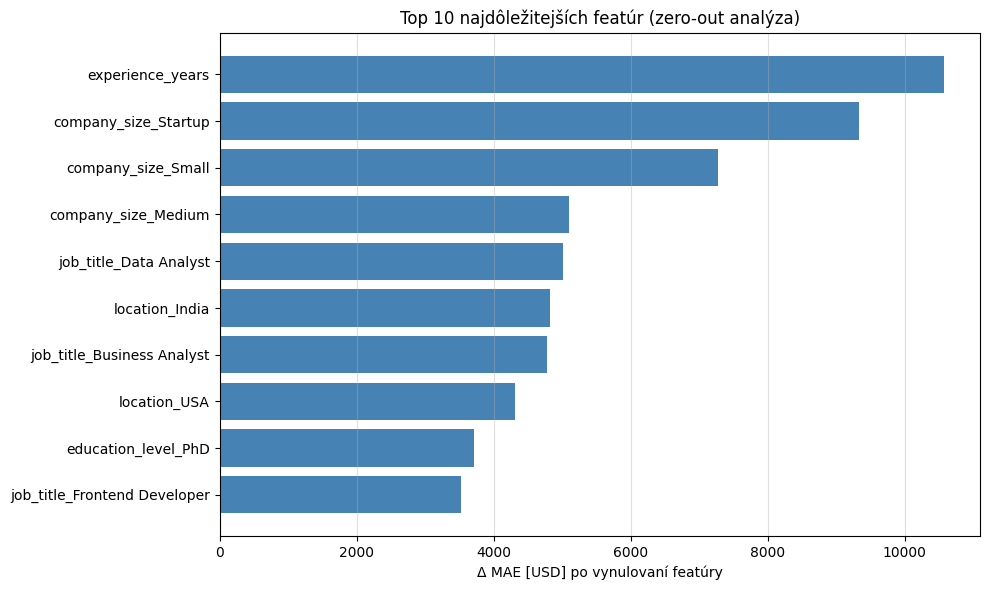

In [19]:
# Mená featúr v poradí ako stĺpce X (po OHE)
feature_names = df_encoded.drop(columns=[target_col]).columns.tolist()

model.eval()

def test_mae_usd(X_data):
    """Test MAE v USD pre dané X (porovnáva s y_test v USD)."""
    X_t = torch.FloatTensor(X_data).to(device)
    with torch.no_grad():
        preds_std = model(X_t).cpu().numpy().flatten()
    preds_usd = preds_std * sigma_y + mu_y
    return float(np.mean(np.abs(preds_usd - y_test)))

# Referenčná MAE (bez perturbácie)
baseline_mae = test_mae_usd(X_test_s)
print(f"Baseline test MAE: {baseline_mae:,.1f} USD")

# Per-feature importance: o koľko stúpne MAE po vynulovaní featúry
importance = {}
for col_idx, col_name in enumerate(feature_names):
    X_perturbed = X_test_s.copy()
    X_perturbed[:, col_idx] = 0.0  # 0 v std priestore ≈ priemer z train
    importance[col_name] = test_mae_usd(X_perturbed) - baseline_mae

# Top 10 najdôležitejších
top10 = sorted(importance.items(), key=lambda kv: kv[1], reverse=True)[:10]

print("\nTop 10 featúr (Δ MAE po vynulovaní):")
for name, score in top10:
    print(f"  {name:40s} {score:>+8.1f} USD")

# Bar chart
names, scores = zip(*top10)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(names)), scores, color="steelblue")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.invert_yaxis()  # najvyššia importance hore
ax.set_xlabel("Δ MAE [USD] po vynulovaní featúry")
ax.set_title("Top 10 najdôležitejších featúr (zero-out analýza)")
ax.grid(True, axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

## 11. Príloha: Prečo tieto voľby? (ReLU, MSE, MAE)

V notebooku sme bez veľkého vysvetlenia siahli po **ReLU** ako aktivácii a **MSE** ako loss funkcii (s **MAE** ako sledovanou metrikou). Existuje ich veľa — tu je odôvodnenie, prečo sú práve tieto rozumná štandardná voľba.

---

### 11.1 Prečo ReLU a nie sigmoid / tanh / iné?

**ReLU** (*Rectified Linear Unit*) je definovaná jednoducho:

$$\text{ReLU}(x) = \max(0, x)$$

Pre porovnanie najznámejšie alternatívy:

| Aktivácia | Vzorec | Výstupný rozsah |
|---|---|---|
| **Sigmoid** | $\sigma(x) = \frac{1}{1+e^{-x}}$ | (0, 1) |
| **Tanh** | $\tanh(x)$ | (−1, 1) |
| **ReLU** | $\max(0, x)$ | [0, ∞) |
| **LeakyReLU** | $\max(0.01x, x)$ | (−∞, ∞) |
| **GELU / SiLU** | hladké varianty ReLU | ≈ ReLU |

**Hlavné dôvody, prečo dnes ReLU dominuje v skrytých vrstvách:**

1. **Žiadny vanishing gradient problem.**
   Sigmoid a tanh sú v "nasýtených" oblastiach (veľké `|x|`) takmer ploché — ich derivácia je blízko 0. Pri spätnej propagácii sa tieto malé gradienty násobia naprieč vrstvami a v hlbších sieťach **úplne zaniknú** → sieť sa prestane učiť. ReLU má pre `x > 0` deriváciu presne `1`, takže gradient prechádza nezmenený.

2. **Výpočtová lacnosť.**
   Sigmoid a tanh počítajú `exp()`, čo je drahšie. ReLU je len `max(0, x)` — jedna porovnávacia operácia. Pri miliónoch neurónov sa to sčíta.

3. **Riedke aktivácie (sparsity).**
   Pre záporné vstupy ReLU vracia 0 — približne polovica neurónov v skrytej vrstve je v ľubovoľnom okamihu "vypnutá". Sieť je efektívnejšia a aktivácie sú lepšie štruktúrované.

4. **Empirický dôkaz.**
   Od roku 2012 (AlexNet) je ReLU defaultom — funguje spoľahlivo naprieč úlohami.

**Známa nevýhoda — *dying ReLU*:**
Ak sa neurón dostane do stavu, kde dostáva iba záporné vstupy, jeho gradient bude nula a už sa nikdy nezotaví. Pre väčšinu úloh to nie je vážny problém, ale ak nastane, pomôžu varianty:
- **LeakyReLU** — pre záporné vstupy nevracia 0, ale `0.01·x` (malý sklon, gradient nikdy nie je 0)
- **ELU / GELU / SiLU (Swish)** — hladké varianty, populárne v transformeroch a moderných sieťach

**Kedy *nepoužiť* ReLU:**
- **Výstupná vrstva binárnej klasifikácie** → sigmoid (potrebuješ pravdepodobnosť 0–1)
- **Výstupná vrstva multi-class klasifikácie** → softmax (pravdepodobnosti, ktoré sa sčítajú do 1)
- **Výstup regresie (ako tu)** → **žiadna aktivácia** (chceme ľubovoľné reálne číslo)
- **Rekurentné siete (LSTM/GRU)** — interne používajú sigmoid a tanh ako brány, tam má fyzický význam

**Záver pre nás:** Štandardný MLP na tabuľkové dáta + regresia → ReLU v skrytých vrstvách je bezpečná a osvedčená voľba. Nemáme veľa vrstiev, takže by fungoval aj tanh, ale ReLU je rýchlejšia a lepšie zaužívaná.

---

### 11.2 Prečo MSE ako loss a MAE ako metrika? Prečo nie iné?

**Dôležitý rozdiel:** *loss* je to, čo optimalizuje optimizer (musí byť pekne diferencovateľné). *Metrika* je to, čo sledujeme my, aby sme rozumeli, ako sa modelu darí (musí byť interpretovateľná).

V notebooku sme zvolili:
- **MSE** ako loss (na ňu sa trénuje)
- **MAE** ako sekundárnu metriku (pre interpretáciu v USD)

#### MSE — Mean Squared Error

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Prečo je dobrá ako loss:**
1. **Hladká a všade diferencovateľná** — jej derivácia je `2(ŷ − y)`, čo je presne to, čo gradient descent potrebuje. Optimizer nielen vie *kam* ísť, ale aj *ako ďaleko* (gradient rastie s veľkosťou chyby → veľké chyby ťahá rýchlejšie nadol).
2. **Trestá veľké chyby kvadraticky.** Chyba 200 USD je 4× horšia ako 100 USD, ale chyba 1000 USD je 100× horšia. Pre platy je to rozumné — jedna predikcia o 50 000 USD vedľa je horšia ako 50 predikcií o 1000 USD vedľa.
3. **Štatisticky dobre zdôvodnená.** Minimalizácia MSE = maximum likelihood pri predpoklade gausovsky rozdeleného šumu okolo cieľa. Pre väčšinu reálnych regresných úloh je to rozumný predpoklad.

**Nevýhody MSE:**
- Hodnota je v **kvadrátoch jednotiek** (USD²) — neinterpretovateľná pre človeka.
- **Citlivá na outliery** — jedna extrémne zlá predikcia môže dominovať loss.

#### MAE — Mean Absolute Error

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

**Prečo ju sledujeme ako metriku:**
1. **Rovnaké jednotky ako target** — MAE = 4090 USD znamená "v priemere sa pomýlim o ~4090 dolárov". Tomu rozumie aj nedataový kolega.
2. **Robustná voči outlierom** — jedna obrovská chyba neovplyvní MAE neprimerane.

**Prečo MAE nepoužívame priamo ako loss:**
- Jej derivácia je len **±1** — optimizer nevie odlíšiť malú chybu od veľkej, všetko ťahá rovnako silno. Konvergencia je pomalšia a často nestabilnejšia, najmä na konci tréningu okolo optima.
- V bode `y = ŷ` derivácia neexistuje (zlom funkcie).

#### Iné regresné metriky a kedy ich použiť

| Metrika | Vzorec | Kedy je vhodná | Prečo nie tu |
|---|---|---|---|
| **RMSE** (Root MSE) | $\sqrt{\text{MSE}}$ | Chceš trest za veľké chyby + jednotky USD | MAE je intuitívnejšia; RMSE je len odmocnina z toho, čo už máme |
| **R²** (koeficient determinácie) | $1 - \frac{\sum(y - \hat{y})^2}{\sum(y - \bar{y})^2}$ | Porovnanie modelov, "koľko variancie sa vysvetlilo" | Bezrozmerná — neinterpretovateľná v USD; môže byť záporná pri zlom modeli |
| **MAPE** (Mean Absolute % Error) | $\frac{1}{n}\sum \left\|\frac{y - \hat{y}}{y}\right\| \cdot 100\%$ | Keď je relatívna chyba dôležitejšia ako absolútna | Pri `y = 0` exploduje; platy nie sú nikdy 0, ale v iných úlohách to môže byť problém |
| **Huber loss** | hybrid MSE/MAE | Robustný tréning na zašumených dátach | Náš dataset má slušnú kvalitu, MSE postačuje |
| **Quantile loss** | asymetrická | Predikcia kvantilov (napr. 90. percentil platu) | My chceme priemernú predikciu, nie distribúciu |

#### A prečo *vôbec nie* metriky z klasifikácie?

**Accuracy, Precision, Recall, F1, Cross-entropy, AUC** — všetky predpokladajú, že existujú **diskrétne triedy**, do ktorých vzorky patria. Plat je spojité číslo: model nepredikuje "trieda 4" alebo "vysoký plat", ale konkrétne číslo (napr. 142 738 USD). Pre regresnú úlohu nemajú zmysel.

---

### Zhrnutie tabuľkou

| Voľba | Naše rozhodnutie | Dôvod |
|---|---|---|
| Aktivácia v skrytých vrstvách | **ReLU** | Žiadny vanishing gradient, lacná, štandardná voľba |
| Aktivácia na výstupe | **žiadna** | Regresia → ľubovoľné reálne číslo |
| Loss funkcia | **MSE** | Hladká, diferencovateľná, trestá veľké chyby, štatisticky podložená |
| Sledovaná metrika | **MAE (v USD)** | Interpretovateľná, robustná, ľahko sa komunikuje |


## Bonusové úlohy (voliteľné)

1. **Dropout:** Pridaj `nn.Dropout(0.3)` po každej ReLU vrstve. Pomôže to? Zmeň sa val MAE?
2. **Hlbšia sieť:** Vyskúšaj architektúru `input → 256 → 128 → 64 → 1`. Čo sa zmení?
3. **Iný optimizer:** Nahraď Adam za SGD s learning rate 0.01. Porovnaj rýchlosť konvergencie.
4. **Normalizácia targetu:** Štandardizuj aj `y` (plat). Pomôže to trénovaniu?
5. **Feature importance:** Nastav všetky hodnoty jedného feature na 0 a sleduj zmenu MAE — ktorý feature je najdôležitejší?